In [1]:
#Paso 1: Importación de librerias

#pandas: Librería para manejar tablas de datos (DataFrames)
#numpy: Para cálculos matemáticos y manejo de valores numéricos (como infinitos)
#matplotlib.pyplot: Para crear todas las visualizaciones y gráficos

#Importaciones:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Esto es para que los gráficos salgan dentro del cuaderno:
%matplotlib inline

# Configuración de estilo del gráfico:
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

In [15]:
#Paso 2: Cargar el Dataset

# Cargar el archivo
# pd.read_csv: Lee el archivo de texto.
# sep='\s+': Indica que las columnas están separadas por uno o más espacios en blanco.

df = pd.read_csv('Pantheon+SH0ES.dat', sep='\s+')

# df.head(): Muestra las primeras 5 filas de la tabla para verificar que las columnas cargaron bien.
df.head()

,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,0.1071,36,26.8859,0.864470,0.0991,1.4960,0.0381,0.005,1.0,0.003
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,0.0579,101,88.3064,0.812220,0.0971,1.4960,-0.0252,0.003,1.0,0.004
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,0.0278,165,233.5000,0.000358,0.0399,0.7134,0.0545,0.019,1.0,0.036
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,0.0667,55,100.1220,0.000193,0.0931,0.7134,0.0622,0.028,1.0,0.040
4,1994DRichmond,50,0.00299,0.00084,0.00299,0.00004,0.00187,0.00004,11.52270,0.880798,...,0.0522,146,109.8390,0.988740,0.0567,0.6110,0.0650,0.009,1.0,0.006


In [16]:
# Paso 3: Estadísticas de la muestra

#Contar total de supernovas (filas)
# len(df): Cuenta cuántas filas totales tiene la tabla (cada fila es una supernova).
total_sn = len(df)

# Identificar calibradores,  donde IS_CALIBRATOR es 1
# Filtrar la tabla original para crear una nueva que solo contenga los "calibradores".
# Los calibradores son SN en galaxias cercanas cuya distancia se conocen por Cefeidas.
calibradores = df[df['IS_CALIBRATOR'] == 1]
total_cal = len(calibradores)

print(f"--- RESUMEN DEL DATASET ---")
print(f"Número total de supernovas en la muestra: {total_sn}")
print(f"Número de supernovas calibradoras (Cefeidas): {total_cal}")
print(f"Número de supernovas no calibradoras: {total_sn - total_cal}")

--- RESUMEN DEL DATASET ---
Número total de supernovas en la muestra: 1701
Número de supernovas calibradoras (Cefeidas): 77
Número de supernovas no calibradoras: 1624


In [17]:
#Paso 4: Limpieza de datos

# Definir las columnas escenciales para los cálculos de las próximas semanas
columnas_clave = ['zCMB', 'zHEL', 'm_b_corr', 'IS_CALIBRATOR']

# .isnull().sum(): Buscar si hay celdas vacías (NaN) en el archivo y sumar por columna.
print("¿Hay valores nulos (vacíos) en las columnas clave?")
print(df[columnas_clave].isnull().sum())

# np.isfinite(...).all(): Verifica que no existan valores "infinitos" o errores de lectura.
# Esto asegura que el código no se rompa al hacer cálculos matemáticos después.
print("\n¿Son todos los valores numéricos finitos?")
print(np.isfinite(df[columnas_clave]).all())

¿Hay valores nulos (vacíos) en las columnas clave?
zCMB             0
zHEL             0
m_b_corr         0
IS_CALIBRATOR    0
dtype: int64

¿Son todos los valores numéricos finitos?
zCMB             True
zHEL             True
m_b_corr         True
IS_CALIBRATOR    True
dtype: bool


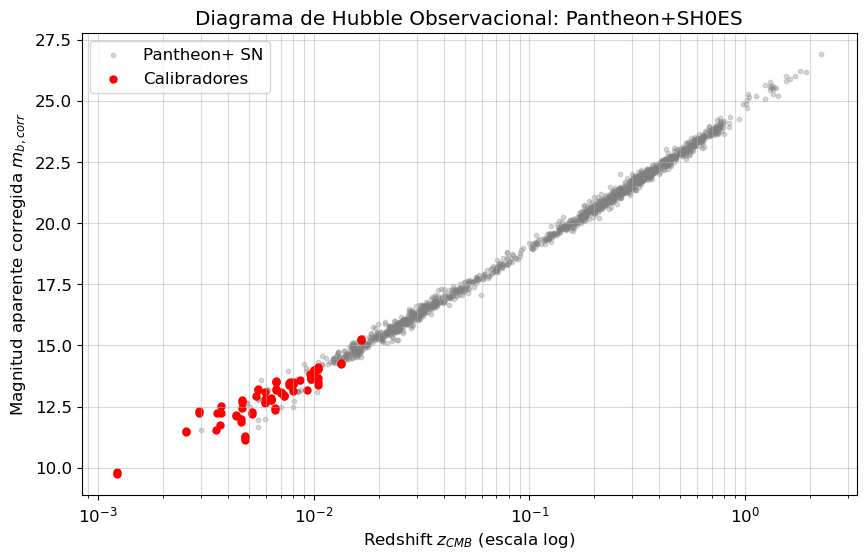

In [18]:
#Paso 5: Gráficas (escala lineal y logarítmica)

plt.figure()

# plt.scatter: Crea un gráfico de puntos. 
# Graficar todas las supernovas en gris con transparencia (alpha=0.3) para ver la densidad.
# zCMB: Redshift corregido al fondo cósmico de microondas (eje X).
# m_b_corr: Magnitud aparente corregida (eje Y).

#Graficar todas las supernovas en gris
plt.scatter(df['zCMB'], df['m_b_corr'], s=10, alpha=0.3, color='gray', label='Pantheon+ SN')

#Resaltar los calibradores en rojo
#Están concentrados en redshifts bajos
plt.scatter(calibradores['zCMB'], calibradores['m_b_corr'], s=25, color='red', label='Calibradores')

# Configuración del gráfico
plt.xscale('log') # Usar escala logarítmica para ver mejor el rango de redshift

plt.xlabel('Redshift $z_{CMB}$ (escala log)')
plt.ylabel('Magnitud aparente corregida $m_{b,corr}$')
plt.title('Diagrama de Hubble Observacional: Pantheon+SH0ES')
plt.legend() #Muestra el cuadro de descripción (gris vs rojo)
plt.grid(True, which="both", ls="-", alpha=0.5) #Cuadrícula

plt.show() #Muestra el gráfico final

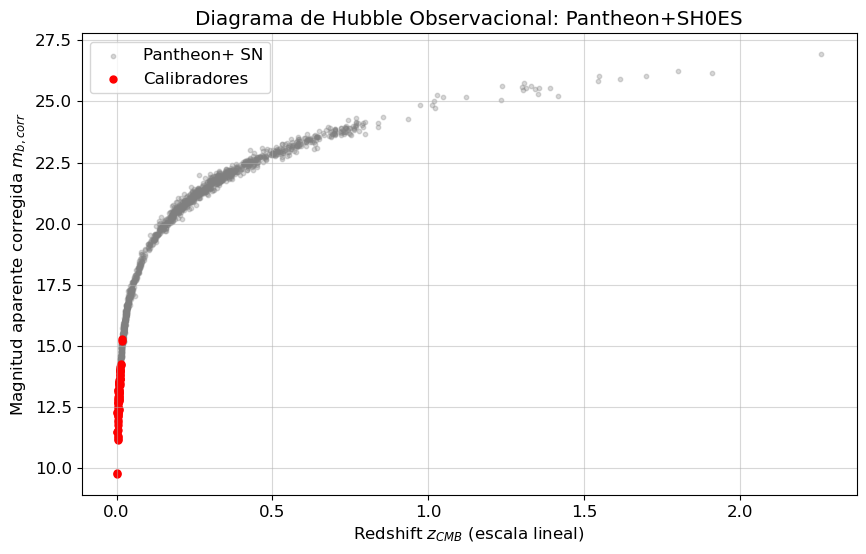

In [20]:
#Paso 5: Gráficas (escala lineal y logarítmica)

plt.figure()

# plt.scatter: Crea un gráfico de puntos. 
# Graficar todas las supernovas en gris con transparencia (alpha=0.3) para ver la densidad.
# zCMB: Redshift corregido al fondo cósmico de microondas (eje X).
# m_b_corr: Magnitud aparente corregida (eje Y).

#Graficar todas las supernovas en gris
plt.scatter(df['zCMB'], df['m_b_corr'], s=10, alpha=0.3, color='gray', label='Pantheon+ SN')

#Resaltar los calibradores en rojo
#Están concentrados en redshifts bajos
plt.scatter(calibradores['zCMB'], calibradores['m_b_corr'], s=25, color='red', label='Calibradores')

# Configuración del gráfico
#plt.xscale('log') # Usar escala logarítmica para ver mejor el rango de redshift

plt.xlabel('Redshift $z_{CMB}$ (escala lineal)')
plt.ylabel('Magnitud aparente corregida $m_{b,corr}$')
plt.title('Diagrama de Hubble Observacional: Pantheon+SH0ES')
plt.legend() #Muestra el cuadro de descripción (gris vs rojo)
plt.grid(True, which="both", ls="-", alpha=0.5) #Cuadrícula

plt.show() #Muestra el gráfico final